# Notebook 02 — Data Preprocessing
Load raw data, remove test_time (leakage), verify quality, save clean dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
print('✅ Libraries loaded')

✅ Libraries loaded


In [2]:
df = pd.read_csv('../data/parkinsons_updrs.csv')
print('Raw shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Raw shape: (5875, 22)
Columns: ['subject#', 'age', 'sex', 'test_time', 'motor_UPDRS', 'total_UPDRS', 'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP', 'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE']


,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,1,72,0,5.6431,28.199,34.398,0.00662,0.000034,0.00401,0.00317,...,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,1,72,0,12.6660,28.447,34.894,0.00300,0.000017,0.00132,0.00150,...,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,1,72,0,19.6810,28.695,35.389,0.00481,0.000025,0.00205,0.00208,...,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014
3,1,72,0,25.6470,28.905,35.810,0.00528,0.000027,0.00191,0.00264,...,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277
4,1,72,0,33.6420,29.187,36.375,0.00335,0.000020,0.00093,0.00130,...,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361


In [3]:
print('=== Dataset Info ===')
df.info()
print('\n=== Statistics ===')
df.describe().round(3)

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 5875 entries, 0 to 5874
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   subject#       5875 non-null   int64  
 1   age            5875 non-null   int64  
 2   sex            5875 non-null   int64  
 3   test_time      5875 non-null   float64
 4   motor_UPDRS    5875 non-null   float64
 5   total_UPDRS    5875 non-null   float64
 6   Jitter(%)      5875 non-null   float64
 7   Jitter(Abs)    5875 non-null   float64
 8   Jitter:RAP     5875 non-null   float64
 9   Jitter:PPQ5    5875 non-null   float64
 10  Jitter:DDP     5875 non-null   float64
 11  Shimmer        5875 non-null   float64
 12  Shimmer(dB)    5875 non-null   float64
 13  Shimmer:APQ3   5875 non-null   float64
 14  Shimmer:APQ5   5875 non-null   float64
 15  Shimmer:APQ11  5875 non-null   float64
 16  Shimmer:DDA    5875 non-null   float64
 17  NHR            5875 non-null   float64
 18

,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
count,5875.000,5875.000,5875.000,5875.000,5875.000,5875.000,5875.000,5875.0,5875.000,5875.000,...,5875.000,5875.000,5875.000,5875.000,5875.000,5875.000,5875.000,5875.000,5875.000,5875.000
mean,21.494,64.805,0.318,92.864,21.296,29.019,0.006,0.0,0.003,0.003,...,0.311,0.017,0.020,0.027,0.051,0.032,21.679,0.541,0.653,0.220
std,12.372,8.822,0.466,53.446,8.129,10.700,0.006,0.0,0.003,0.004,...,0.230,0.013,0.017,0.020,0.040,0.060,4.291,0.101,0.071,0.091
min,1.000,36.000,0.000,-4.262,5.038,7.000,0.001,0.0,0.000,0.000,...,0.026,0.002,0.002,0.002,0.005,0.000,1.659,0.151,0.514,0.022
25%,10.000,58.000,0.000,46.848,15.000,21.371,0.004,0.0,0.002,0.002,...,0.175,0.009,0.011,0.016,0.028,0.011,19.406,0.470,0.596,0.156
50%,22.000,65.000,0.000,91.523,20.871,27.576,0.005,0.0,0.002,0.002,...,0.253,0.014,0.016,0.023,0.041,0.018,21.920,0.542,0.644,0.206
75%,33.000,72.000,1.000,138.445,27.596,36.399,0.007,0.0,0.003,0.003,...,0.365,0.021,0.024,0.033,0.062,0.031,24.444,0.614,0.711,0.264
max,42.000,85.000,1.000,215.490,39.511,54.992,0.100,0.0,0.058,0.070,...,2.107,0.163,0.167,0.275,0.488,0.748,37.875,0.966,0.866,0.732


In [4]:
print('Missing values:', df.isnull().sum().sum())
print('Duplicate rows:', df.duplicated().sum())
print('Unique subjects:', df['subject#'].nunique())
print('Avg recordings/subject:', round(len(df)/df['subject#'].nunique(),1))

Missing values: 0
Duplicate rows: 0
Unique subjects: 42
Avg recordings/subject: 139.9


In [5]:
# Remove test_time only (temporal leakage — not available at prediction time)
# motor_UPDRS is KEPT — it is a valid predictor (recorded simultaneously by device)
df_clean = df.drop(columns=['test_time'])
print('Clean shape:', df_clean.shape)
print('Columns kept:', df_clean.columns.tolist())

Clean shape: (5875, 21)
Columns kept: ['subject#', 'age', 'sex', 'motor_UPDRS', 'total_UPDRS', 'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP', 'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE']


In [6]:
TARGET = 'total_UPDRS'
feature_cols = df_clean.drop(columns=[TARGET, 'subject#']).columns.tolist()
print(f'Features ({len(feature_cols)}):', feature_cols)
print(f'\nTarget range: {df_clean[TARGET].min():.2f} — {df_clean[TARGET].max():.2f}')
print(f'Target mean:  {df_clean[TARGET].mean():.2f} ± {df_clean[TARGET].std():.2f}')

Features (19): ['age', 'sex', 'motor_UPDRS', 'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP', 'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE']

Target range: 7.00 — 54.99
Target mean:  29.02 ± 10.70


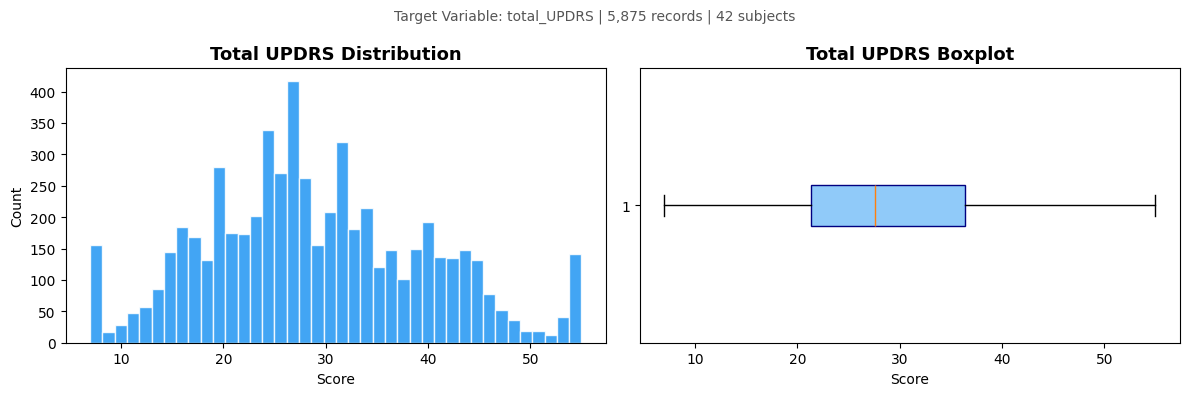

✅ Saved: figures/01_target_distribution.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_clean[TARGET], bins=40, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0].set_title('Total UPDRS Distribution', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Score'); axes[0].set_ylabel('Count')
axes[1].boxplot(df_clean[TARGET], vert=False, patch_artist=True,
               boxprops=dict(facecolor='#90CAF9', color='navy'))
axes[1].set_title('Total UPDRS Boxplot', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Score')
plt.suptitle('Target Variable: total_UPDRS | 5,875 records | 42 subjects', fontsize=10, color='#555')
plt.tight_layout()
plt.savefig('../figures/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: figures/01_target_distribution.png')

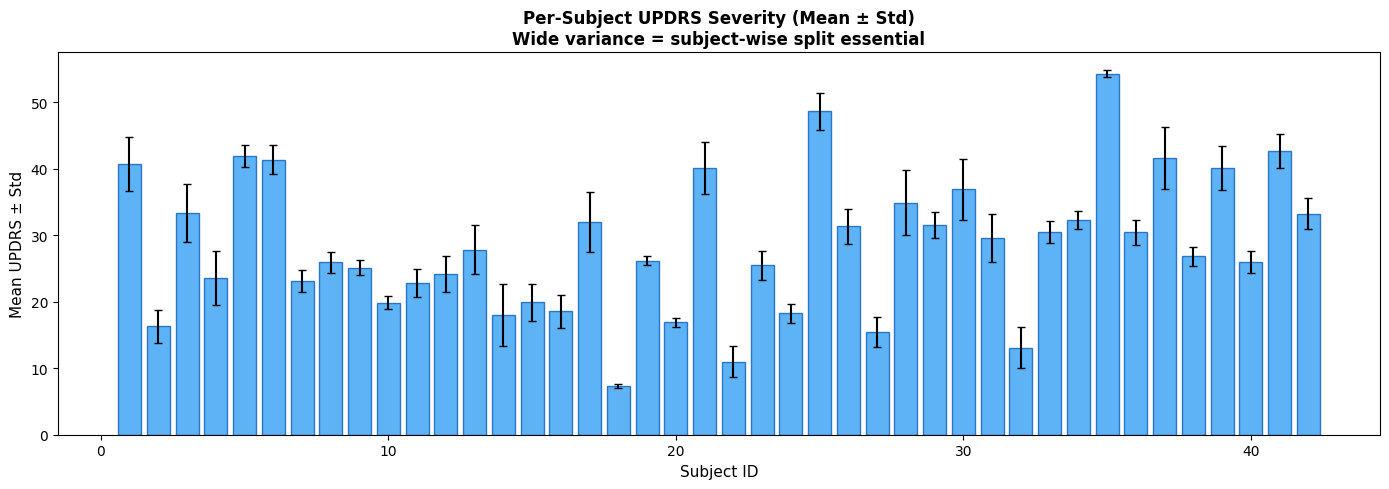

✅ Saved: figures/02_subject_updrs.png


In [8]:
# Per-subject UPDRS stats
subj_stats = df_clean.groupby('subject#')[TARGET].agg(['mean','std','count'])
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(subj_stats.index, subj_stats['mean'], yerr=subj_stats['std'],
       capsize=3, color='#42A5F5', edgecolor='#1565C0', alpha=0.85)
ax.set_xlabel('Subject ID', fontsize=11)
ax.set_ylabel('Mean UPDRS ± Std', fontsize=11)
ax.set_title('Per-Subject UPDRS Severity (Mean ± Std)\nWide variance = subject-wise split essential',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('../figures/02_subject_updrs.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: figures/02_subject_updrs.png')

In [9]:
df_clean.to_csv('../data/clean_parkinsons.csv', index=False)
print('✅ Saved: data/clean_parkinsons.csv')
print('Final shape:', df_clean.shape)

✅ Saved: data/clean_parkinsons.csv
Final shape: (5875, 21)


## ✅ Preprocessing Summary
- **5,875 records | 42 subjects | 0 missing | 0 duplicates**
- Removed: `test_time` (temporal leakage)
- Kept: `motor_UPDRS` (valid clinical predictor)
- **20 features** total (subject# used only for split)
- Target: continuous regression task